In [1]:
import numpy as np
import matplotlib.pyplot as plt

In [2]:
# plotting parameters
plt.rc('axes', labelsize=10)
plt.rc('axes', labelweight='regular')
plt.rc('axes', titleweight='regular')
plt.rc('axes', linewidth=1)
plt.rc('xtick',labelsize=10,direction='in',top=True)
plt.rc('ytick',labelsize=10,direction='in',right=True)
plt.rcParams['xtick.major.pad']='10'
plt.rcParams['ytick.major.pad']='10'

paper_params = {'text.usetex' : True,
           'font.size' : 14,
           'font.family' : 'lmodern',
           'figure.dpi' : 200,
           }
plt.rcParams.update(paper_params)
## 3.5 x 3 inch figure size for single column in paper
## 7 x 3 inch figure size for two column in paper

C_RGB
Cno_RGB
EMP_RGB
MP_RGB


(-0.25, 2.65)

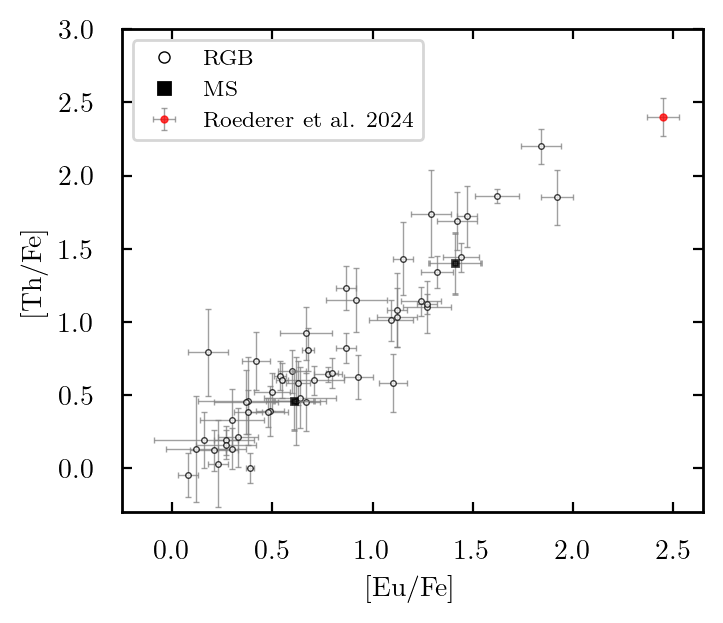

In [3]:
# directories
SAGA_dir = '/Users/dimoff/SAGA_database_outputs/Radiogenics'

# Th vs Eu data
Th_Eu_files = !ls {SAGA_dir}/Th_Eu/Th_Eu_*

fig, ax = plt.subplots(figsize=(3.5,3), dpi=200, constrained_layout=True)
ax.set_xlabel(r'[Eu/Fe]')
ax.set_ylabel(r'[Th/Fe]')

# read the data files from the Th_Eu_dir
for file in Th_Eu_files:
    #print(file)
    # set name of dataset by file name
    data_name = file.split('/')[-1].split('.')[0].split('Eu_')[-1]
    #print(data_name)

    if data_name == 'Cs_MS':
        continue
    elif data_name == 'Cs_RGB':
        continue

    if 'RGB' in data_name:
        print(data_name)
        data_name = 'RGB'
        markeredgecolor = 'k'
        markerfacecolor = 'white'
        markeredgewidth = 0.5
        marker = '.'
        markersize = 4
        zorder=2
    else:# 'MS' in data_name:
        #print(data_name)
        data_name = 'MS'
        markeredgecolor = 'k'
        markerfacecolor = 'k'
        markeredgewidth = 1.0
        marker = 's'
        markersize = 2
        zorder=4

    data = np.genfromtxt(file, skip_header=1, dtype=np.float64).T

    # split data by columns
    Th_data = data[0]
    Th_err_plus = data[2]
    Th_err_minus = data[3]

    Eu_data = data[1]
    Eu_err = data[4]

    for Eu, Th, Eu_err, Th_err in zip(Eu_data, Th_data, Eu_err, Th_err_plus):

        # ian identified a star that is anomolous, so we remove it
        if Eu > 1.9 and Th > 2.4:
            continue
        if  Eu_err < 0:
            Eu_err = -1 * Eu_err
        if Th_err < 0:
            Th_err = -1 * Th_err

        #if Eu_err !=0 and Th_err != 0:
        if Th_err != 0 and Eu_err != 0:
            ax.errorbar(Eu, Th, xerr=Eu_err, yerr=Th_err, marker=marker, markeredgecolor=markeredgecolor,
                    markerfacecolor=markerfacecolor, markeredgewidth=markeredgewidth, markersize=markersize, 
                    ecolor='grey', elinewidth=0.5, capsize=1.0, capthick=0.5, alpha=0.75, zorder=zorder)
            
            #ax.quiver(Eu, Th, 0, -0.5, angles='xy', scale_units='xy', scale=1, color='grey', width=0.002, alpha=0.75)
            #ax.quiver(Eu, Th, -0.5, 0, angles='xy', scale_units='xy', scale=1, color='grey', width=0.002, alpha=0.75)
        else:
            continue
        #elif Eu_err == 0 or np.isnan(Eu_err) or Eu_err < 0: 
        #    ax.quiver(Eu, Th, -0.5, 0, angles='xy', scale_units='xy', scale=1, color='grey', width=0.002, alpha=0.75)


        # plot quivers for upper limits
        # Th upper limits if the error is 0 or negative or nan
        #if Th_err == 0 or np.isnan(Th_err) or Th_err < 0: 
            # plot quiver as upper limit on Th with arrow pointing left
        #    ax.quiver(Eu, Th, 0, -0.5, angles='xy', scale_units='xy', scale=1, color='grey', width=0.002, alpha=0.75)
        # Eu upper limits if the error is 0 or negative or nan
        #if Eu_err == 0 or np.isnan(Eu_err) or Eu_err < 0:
            # plot quiver as upper limit on Eu with arrow pointing down
        #    ax.quiver(Eu, Th, -0.5, 0, angles='xy', scale_units='xy', scale=1, color='grey', width=0.002, alpha=0.75)

# plot the Roederer star with Eu = +2.45 and Th = +2.20
ax.errorbar(2.45, 2.40, xerr=0.08, yerr=0.13, marker='o', markerfacecolor='red', markeredgecolor='red', markeredgewidth = 0.5, color='None', markersize=2.5, 
            ecolor='grey', elinewidth=0.5, capsize=1.0, capthick=0.5, alpha=0.75, label='Roederer et al. 2024')

# plot legend
# RGBs
ax.plot([], [], marker='.', markeredgecolor='k', markerfacecolor='white', markeredgewidth=0.5, linestyle='None', markersize=8, label='RGB')
# MSs
ax.plot([], [], marker='s', color='k', linestyle='None', markersize=4, label='MS')

ax.legend(frameon=True, loc='upper left',fontsize=8)
ax.set_ylim(-0.30, 3.0)
ax.set_xlim(-0.25, 2.65)

In [4]:
# great, Th follows Eu. This is not new.

In [47]:
# plot Eu/Fe, Th/Fe, and U/Fe vs Fe/H in the same plot. 
#SAGA_dir
Th_Fe_files = !ls {SAGA_dir}/Th_Fe/Th_Fe_*
U_Fe_files = !ls {SAGA_dir}/U_Fe/U_Fe_*
Eu_Fe_files = !ls {SAGA_dir}/Eu_Fe/Eu_Fe_*
Eu_Fe_files

['/Users/dimoff/SAGA_database_outputs/Radiogenics/Eu_Fe/Eu_Fe_CEMP_MS',
 '/Users/dimoff/SAGA_database_outputs/Radiogenics/Eu_Fe/Eu_Fe_CEMP_RGB',
 '/Users/dimoff/SAGA_database_outputs/Radiogenics/Eu_Fe/Eu_Fe_C_MS',
 '/Users/dimoff/SAGA_database_outputs/Radiogenics/Eu_Fe/Eu_Fe_C_RGB',
 '/Users/dimoff/SAGA_database_outputs/Radiogenics/Eu_Fe/Eu_Fe_Cno_MS',
 '/Users/dimoff/SAGA_database_outputs/Radiogenics/Eu_Fe/Eu_Fe_Cno_RGB',
 '/Users/dimoff/SAGA_database_outputs/Radiogenics/Eu_Fe/Eu_Fe_Cs_MS',
 '/Users/dimoff/SAGA_database_outputs/Radiogenics/Eu_Fe/Eu_Fe_Cs_RGB',
 '/Users/dimoff/SAGA_database_outputs/Radiogenics/Eu_Fe/Eu_Fe_EMP_MS',
 '/Users/dimoff/SAGA_database_outputs/Radiogenics/Eu_Fe/Eu_Fe_EMP_RGB',
 '/Users/dimoff/SAGA_database_outputs/Radiogenics/Eu_Fe/Eu_Fe_MP']

(-4.25, 0.65)

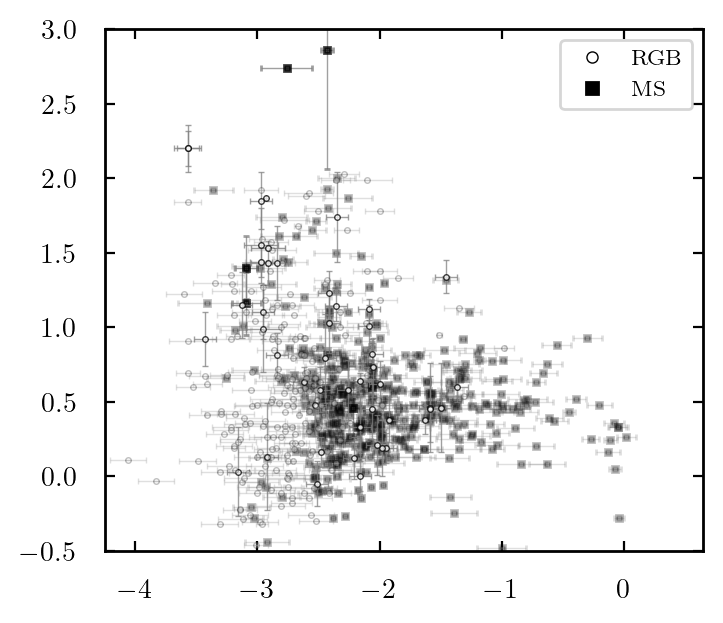

In [56]:
fig, ax = plt.subplots(1,1, figsize=(3.5,3), constrained_layout=True, dpi=200)

for file in Th_Fe_files:
    #print(file)
    # set name of dataset by file name
    data_name = file.split('/')[-1].split('.')[0]
    #print(data_name)

    if 'RGB' in data_name:
        #print(data_name)
        data_name = 'RGB'
        markeredgecolor = 'k'
        markerfacecolor = 'white'
        markeredgewidth = 0.5
        marker = '.'
        markersize = 4
        zorder=4
    else:# 'MS' in data_name:
        #print(data_name)
        data_name = 'MS'
        markeredgecolor = 'k'
        markerfacecolor = 'k'
        markeredgewidth = 1.0
        marker = 's'
        markersize = 2
        zorder=2

    data = np.genfromtxt(file, skip_header=1, dtype=np.float64).T

    # split data by columns
    Fe_data = data[0]
    Fe_err_plus = data[2]
    Fe_err_minus = data[3]
    Fe_err = np.nanmedian([Fe_err_plus, Fe_err_minus])

    Th_data = data[1]
    Th_err = data[4]

    try:
        if np.dtype(Th_data) == np.float64:
            ax.errorbar(Fe_data, Th_data, xerr=Fe_err, yerr=Th_err, marker=marker, markeredgecolor=markeredgecolor,
                            markerfacecolor=markerfacecolor, markeredgewidth=markeredgewidth, markersize=markersize, 
                            ecolor='grey', elinewidth=0.5, capsize=1.0, capthick=0.5, alpha=0.75, zorder=zorder)
    
    except:
        for Fe, Th, Fe_err, Th_err in zip(Fe_data, Th_data, Fe_err_plus, Th_err):

            # ian identified a star that is anomolous, so we remove it
            if Th > 2.4:
                continue
            if Th_err < 0:
                Th_err = -1 * Th_err

            if Th_err != 0 and Fe_err != 0:
                ax.errorbar(Fe, Th, xerr=Eu_err, yerr=Th_err, marker=marker, markeredgecolor=markeredgecolor,
                        markerfacecolor=markerfacecolor, markeredgewidth=markeredgewidth, markersize=markersize, 
                        ecolor='grey', elinewidth=0.5, capsize=1.0, capthick=0.5, alpha=0.75, zorder=zorder)

                #ax.quiver(Eu, Th, 0, -0.5, angles='xy', scale_units='xy', scale=1, color='grey', width=0.002, alpha=0.75)
                #ax.quiver(Eu, Th, -0.5, 0, angles='xy', scale_units='xy', scale=1, color='grey', width=0.002, alpha=0.75)
            else:
                continue
            #elif Eu_err == 0 or np.isnan(Eu_err) or Eu_err < 0: 
            #    ax.quiver(Eu, Th, -0.5, 0, angles='xy', scale_units='xy', scale=1, color='grey', width=0.002, alpha=0.75)

for file in U_Fe_files:
    #print(file)
    # set name of dataset by file name
    data_name = file.split('/')[-1].split('.')[0]
    #print(data_name)

    if 'RGB' in data_name:
        #print(data_name)
        data_name = 'RGB'
        markeredgecolor = 'k'
        markerfacecolor = 'white'
        markeredgewidth = 0.5
        marker = '.'
        markersize = 4
        zorder=4
    else:# 'MS' in data_name:
        #print(data_name)
        data_name = 'MS'
        markeredgecolor = 'k'
        markerfacecolor = 'k'
        markeredgewidth = 1.0
        marker = 's'
        markersize = 2
        zorder=2

    data = np.genfromtxt(file, skip_header=1, dtype=np.float64).T

    # split data by columns
    Fe_data = data[0]
    Fe_err_plus = data[2]
    Fe_err_minus = data[3]
    Fe_err = np.nanmedian([Fe_err_plus, Fe_err_minus])

    U_data = data[1]
    U_err = data[4]

    try:
        if np.dtype(U_data) == np.float64:
            ax.errorbar(Fe_data, U_data, xerr=Fe_err, yerr=U_err, marker=marker, markeredgecolor=markeredgecolor,
                            markerfacecolor=markerfacecolor, markeredgewidth=markeredgewidth, markersize=markersize, 
                            ecolor='grey', elinewidth=0.5, capsize=1.0, capthick=0.5, alpha=0.75, zorder=zorder)
    
    except:
        for Fe, U, Fe_err, U_err in zip(Fe_data, U_data, Fe_err_plus, U_err):

            #if Eu_err !=0 and Th_err != 0:
            if U_err != 0 and Fe_err != 0:
                ax.errorbar(Fe, U, xerr=Fe_err, yerr=U_err, marker=marker, markeredgecolor=markeredgecolor,
                        markerfacecolor=markerfacecolor, markeredgewidth=markeredgewidth, markersize=markersize, 
                        ecolor='grey', elinewidth=0.5, capsize=1.0, capthick=0.5, alpha=0.75, zorder=zorder)

                #ax.quiver(Eu, Th, 0, -0.5, angles='xy', scale_units='xy', scale=1, color='grey', width=0.002, alpha=0.75)
                #ax.quiver(Eu, Th, -0.5, 0, angles='xy', scale_units='xy', scale=1, color='grey', width=0.002, alpha=0.75)
            else:
                continue
            #elif Eu_err == 0 or np.isnan(Eu_err) or Eu_err < 0: 
            #    ax.quiver(Eu, Th, -0.5, 0, angles='xy', scale_units='xy', scale=1, color='grey', width=0.002, alpha=0.75)

for file in Eu_Fe_files:
    #print(file)
    # set name of dataset by file name
    data_name = file.split('/')[-1].split('.')[0]
    #print(data_name)

    if 'RGB' in data_name:
        #print(data_name)
        data_name = 'RGB'
        markeredgecolor = 'k'
        markerfacecolor = 'white'
        markeredgewidth = 0.5
        marker = '.'
        markersize = 4
        zorder=4
        alpha=0.25
    else:# 'MS' in data_name:
        #print(data_name)
        data_name = 'MS'
        markeredgecolor = 'k'
        markerfacecolor = 'k'
        markeredgewidth = 1.0
        marker = 's'
        markersize = 2
        zorder=2
        alpha=0.25

    data = np.genfromtxt(file, skip_header=1, dtype=np.float64).T

    # split data by columns
    Fe_data = data[0]
    Fe_err_plus = data[2]
    Fe_err_minus = data[3]
    Fe_err = np.nanmedian([Fe_err_plus, Fe_err_minus])

    Eu_data = data[1]
    Eu_err = data[4]

    try:
        if np.dtype(Eu_data) == np.float64:
            ax.errorbar(Fe_data, Eu_data, xerr=Fe_err, yerr=U_err, marker=marker, markeredgecolor=markeredgecolor,
                            markerfacecolor=markerfacecolor, markeredgewidth=markeredgewidth, markersize=markersize, 
                            ecolor='grey', elinewidth=0.5, capsize=1.0, capthick=0.5, alpha=alpha, zorder=zorder)
    
    except:
        for Fe, Eu, Fe_err, Eu_err in zip(Fe_data, Eu_data, Fe_err_plus, Eu_err):

            #if Eu_err !=0 and Th_err != 0:
            if Eu_err != 0 and Fe_err != 0:
                ax.errorbar(Fe, Eu, xerr=Fe_err, yerr=U_err, marker=marker, markeredgecolor=markeredgecolor,
                        markerfacecolor=markerfacecolor, markeredgewidth=markeredgewidth, markersize=markersize, 
                        ecolor='grey', elinewidth=0.5, capsize=1.0, capthick=0.5, alpha=alpha, zorder=zorder)

                #ax.quiver(Eu, Th, 0, -0.5, angles='xy', scale_units='xy', scale=1, color='grey', width=0.002, alpha=0.75)
                #ax.quiver(Eu, Th, -0.5, 0, angles='xy', scale_units='xy', scale=1, color='grey', width=0.002, alpha=0.75)
            else:
                continue
            #elif Eu_err == 0 or np.isnan(Eu_err) or Eu_err < 0: 
            #    ax.quiver(Eu, Th, -0.5, 0, angles='xy', scale_units='xy', scale=1, color='grey', width=0.002, alpha=0.75)

# plot the Roederer star with Eu = +2.45 and Th = +2.20
#ax.errorbar(2.45, 2.40, xerr=0.08, yerr=0.13, marker='o', markerfacecolor='red', markeredgecolor='red', markeredgewidth = 0.5, color='None', markersize=2.5, 
#            ecolor='grey', elinewidth=0.5, capsize=1.0, capthick=0.5, alpha=0.75, label='Roederer et al. 2024')

# plot legend
# RGBs
ax.plot([], [], marker='.', markeredgecolor='k', markerfacecolor='white', markeredgewidth=0.5, linestyle='None', markersize=8, label='RGB')
# MSs
ax.plot([], [], marker='s', color='k', linestyle='None', markersize=4, label='MS')

ax.legend(frameon=True, loc='upper right',fontsize=8)
ax.set_ylim(-0.50, 3.0)
ax.set_xlim(-4.25, 0.65)